# **Exploracion vs Explotacion**

**Apellido y Nombre:** Vasquez Caiza Juan Marcelo.

**Carrera:** Ingenieria de Sistemas.

# **El juego del repartidor de pizzas**
El repartido de pizzas debe realizar entregas, y cuenta con 5 rutas diferentes para hacer sus entregas. Cada ruta nos proporciona una recompensa(Propina) pero no sabemos al inicio cual es la mejor.
Para descubrirlo, el repartidor debe decidir qué ruta tomar cada vez que hace una entrega:
- Si repite siempre la misma ruta, puede estar perdiendo una mejor oportunidad.

- Si cambia demasiado, no aprende bien cuál es realmente la más rentable.

Entonces, el repartidor combina dos comportamientos:

Explorar -> probar nuevas rutas para obtener más información.

Explotar -> elegir la ruta que hasta ahora le ha dado mejores resultados.

Con el tiempo, va actualizando sus estimaciones de cada ruta (llamadas q[ruta] en el código), y así aprende a tomar mejores decisiones.
La función obtener_recompensa(ruta) representa la propina o ganancia aleatoria que recibe al tomar una ruta, basada en su promedio (q[ruta]), simulando que no siempre se gana lo mismo.


# **Metodo de accion-Valor**


In [29]:
import numpy as np
import matplotlib.pyplot as plt

rutas = {1:"Centro",2:"Norte",3:"Sur",4:"Este",5:"Oeste"}
q = {1: 1.0, 2: 1.5, 3: 2.0, 4: 1.2, 5: 1.8}

def obtener_recompensa(ruta):
    media = q[ruta]
    return np.random.normal(media,0.3)

In [30]:
partidas = 1000
turnos = 150
epsilons = [0,0.01,0.1]

recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

for pt in range(partidas):
    mejor_accion = max(q, key = q.get)
    for i, e in enumerate(epsilons):

        Q = {k: 0 for k in range(1,6)}
        acciones = {k: 0 for k in range(1,6)}
        recompensas = {k: 0 for k in range(1,6)}
        for exp in range(turnos):

            if np.random.uniform(0,1) < e:
                a = np.random.randint(5) + 1
            else:
                maxQ = -100
                for j in range(1,6):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        a = j
            acciones[a] += 1
            recompensa = obtener_recompensa(a)
            recompensas[a] += recompensa
            Q[a] = recompensas[a]/acciones[a]
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

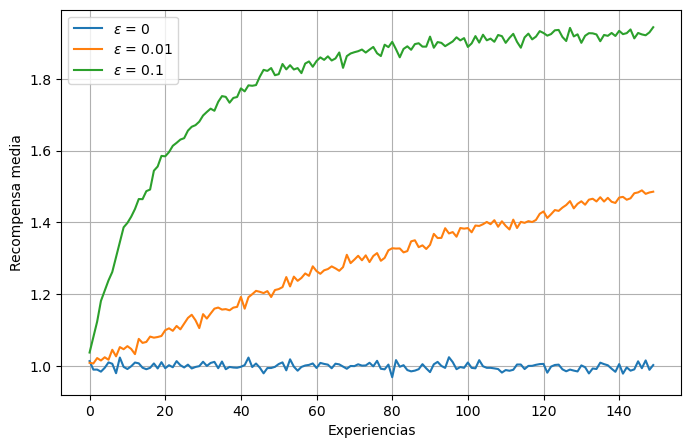

In [31]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()

# **Implementacion incremental**

In [32]:
partidas = 1000
turnos = 150
alpha = 0.5
epsilons = [0.0, 0.01, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

for pt in range(partidas):
    mejor_accion = max(q, key=q.get)
    for i,e in enumerate(epsilons):
        Q = {k:0 for k in range(1,6)}
        for exp in range(turnos):
            if np.random.uniform(0,1) < e:
                a = np.random.randint(5) + 1
            else:
                maxQ = -100
                for j in range(1,6):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        a = j
            recompensa = obtener_recompensa(a)
            Q[a] += alpha*(recompensa - Q[a])
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

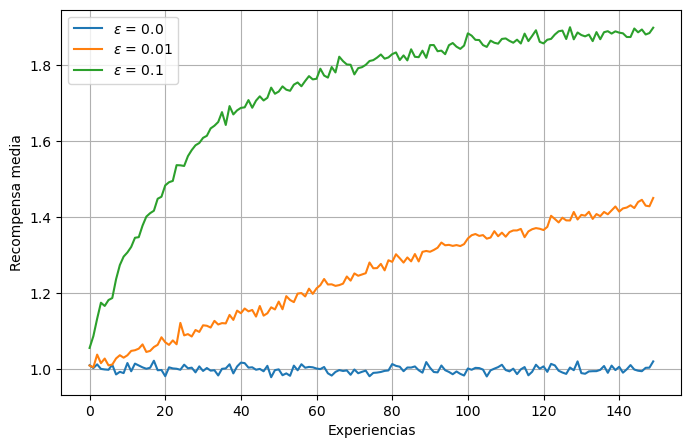

In [33]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()

# **Valores iniciales optimistas**

In [34]:
partidas = 1000
turnos = 150
alpha = 0.5
epsilons = [0, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

for pt in range(partidas):
    mejor_accion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1,6)}
        if e == 0:  ##Si el agente es greedy inicializamos con valores altos
            Q = {k: 5 for k in range(1,6)}
        for exp in range(turnos):
            if np.random.uniform(0,1) < e:
                a = np.random.randint(5) + 1
            else:
                maxQ = -100
                for j in range(1,6):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        a = j
            recompensa = obtener_recompensa(a)
            Q[a] += alpha*(recompensa - Q[a])
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

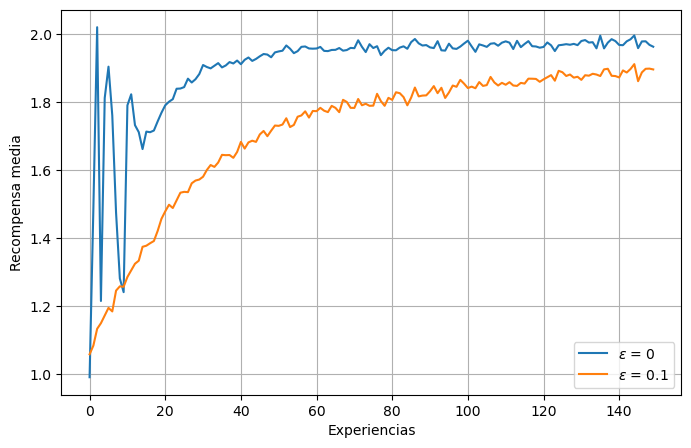

In [35]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()

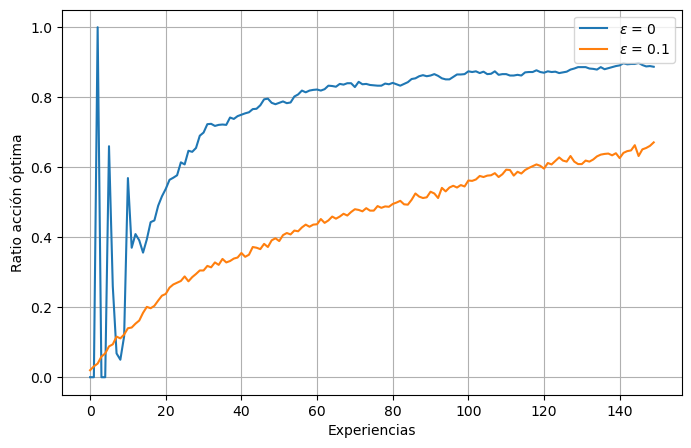

In [36]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(acciones_optimas[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Ratio acción óptima')
plt.show()

# **Seleccion de acciones con intervalo de confianza (UCB)**

In [54]:
import math

partidas = 1000
turnos = 500
alpha= 0.5
c = 1
epsilons = [0.1, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

for pt in range(partidas):
    mejor_accion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1,6)}
        acciones = {k: 1 for k in range(1,6)}
        for exp in range(turnos):
            if i == 0: # UCB
                maxQ = -100
                for j in range(1, 6):
                    A = Q[j] + c*math.sqrt(math.log(exp+1)/(acciones[j]))
                    if A > maxQ:
                        maxQ = A
                        a = j
            else:
                
                if np.random.uniform(0,1) < e:
                    
                    a = np.random.randint(5) + 1
                else:
                    
                    maxQ = -100
                    for j in range(1, 6):
                        if Q[j] > maxQ:
                            maxQ = Q[j]
                            a = j
            acciones[a] += 1
            recompensa = q[a] ##obtener_recompensa(a) 
            Q[a] += alpha*(recompensa - Q[a])
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

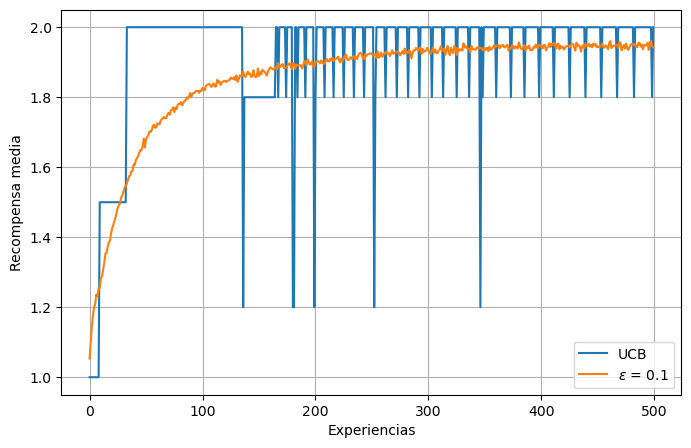

In [55]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}' if i != 0 else "UCB")
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()

# **Algoritmos de gradiente**

In [39]:
def softmax(x):
    return np.exp(x)/sum(np.exp(x))

In [40]:
partidas = 1000
turnos = 150
alphas = [0.1, 0.4]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))
for pt in range(partidas):
    mejor_accion = max(q, key=q.get)
    for i, alpha in enumerate(alphas):
        H = np.zeros(5)
        pi = softmax(H)
        recompensas = []
        for exp in range(turnos):
            # elegir acción
            a = np.random.choice(range(1,6),1,p=pi)[0]
            recompensa = obtener_recompensa(a)
            recompensas.append(recompensa)
            recompensa_media = np.mean(recompensas)
            # actualizar preferencias
            for j in range(5):
                if j == a-1:
                    H[j] += alpha*(recompensa - recompensa_media)*(1-pi[j])
                else:
                    H[j] -= alpha*(recompensa - recompensa_media)*pi[j]
            # actualizar probabilidades
            pi = softmax(H)
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

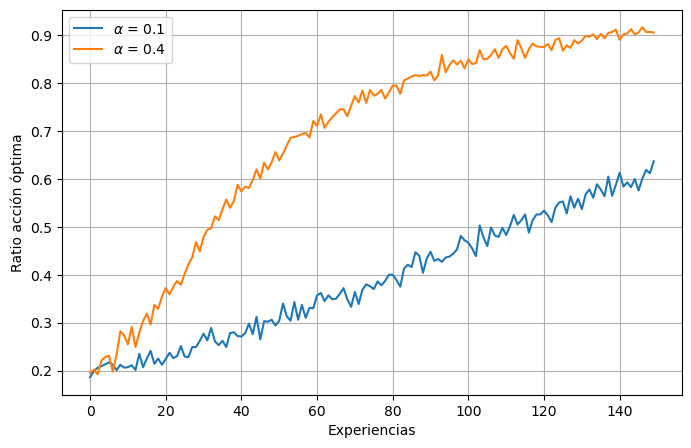

In [41]:
plt.figure(figsize=(8,5))
for i, a in enumerate(alphas):
    plt.plot(acciones_optimas[i], label=fr'$\alpha$ = {a}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Ratio acción óptima')
plt.show()